## Cluster Sounds
Groups detected sound units into categories using K-Means clustering.
See `docs/cluster_sounds.md` for theory.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import json


## Load Features

In [2]:
features    = np.load('../data/unit_features.npy')
onset_times = np.load('../data/onset_times.npy')

print(f'feature matrix : {features.shape}  (units × features)')
print(f'feature names  : dominant_freq, duration, mean_rms, spectral_centroid')
print()
print(f'value ranges:')
names = ['dominant_freq', 'duration', 'mean_rms', 'centroid']
for i, name in enumerate(names):
    print(f'  {name:20} min={features[:,i].min():.3f}  max={features[:,i].max():.3f}')

feature matrix : (28, 4)  (units × features)
feature names  : dominant_freq, duration, mean_rms, spectral_centroid

value ranges:
  dominant_freq        min=200.000  max=2403.606
  duration             min=0.071  max=0.788
  mean_rms             min=0.116  max=0.427
  centroid             min=203.125  max=2906.335


## Normalize features
Features are on very different scales — frequency in hundreds, duration in milliseconds.
Normalization puts them all on equal footing before clustering.


In [3]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print('after normalization — all features centered at 0, std=1:')
for i, name in enumerate(names):
    print(f'  {name:20} mean={features_scaled[:,i].mean():.3f}  std={features_scaled[:,i].std():.3f}')

after normalization — all features centered at 0, std=1:
  dominant_freq        mean=0.000  std=1.000
  duration             mean=0.000  std=1.000
  mean_rms             mean=0.000  std=1.000
  centroid             mean=-0.000  std=1.000


## Find the right number of clusters — elbow method
Run K-Means for K=2 to K=20, plot inertia. Look for the elbow — where adding more clusters stops helping much.

c:\Users\Admin\anaconda3\envs\rocky_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\rocky_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\rocky_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\anaconda3\envs\rocky_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: 

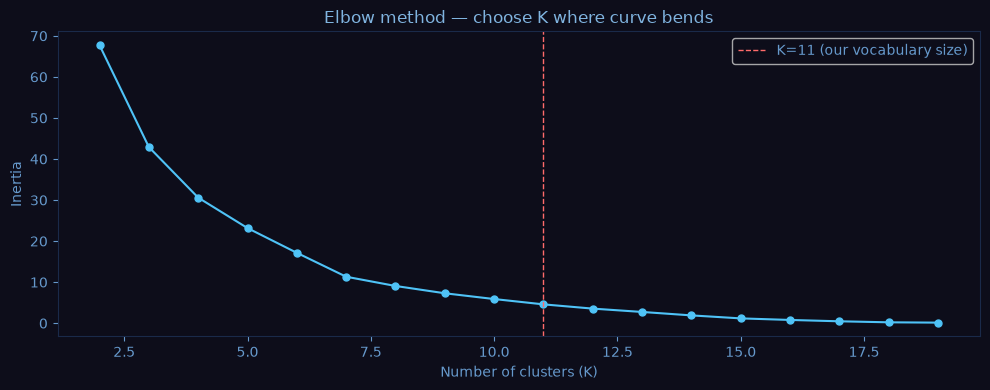

we defined 11 sound types in synthesis — using K=11


In [4]:
inertias = []
K_range  = range(2, 20)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.tick_params(colors='#6699cc')
ax.xaxis.label.set_color('#6699cc')
ax.yaxis.label.set_color('#6699cc')
for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

ax.plot(list(K_range), inertias, color='#4fc3f7', marker='o', markersize=5, linewidth=1.5)
ax.set(title='Elbow method — choose K where curve bends', xlabel='Number of clusters (K)', ylabel='Inertia')
ax.title.set_color('#80b4e0')
ax.axvline(x=11, color='#ff6b6b', linewidth=1, linestyle='--', label='K=11 (our vocabulary size)')
ax.legend(facecolor='#0d0d1a', labelcolor='#6699cc')
plt.tight_layout()
plt.savefig('../audio/elbow_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('we defined 11 sound types in synthesis — using K=11')

## Run K-Means with K=11

In [5]:
K = 11
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(features_scaled)

print(f'K-Means done. {K} clusters assigned to {len(labels)} units.')
print()
print('units per cluster:')
for k in range(K):
    count = np.sum(labels == k)
    bar   = '█' * count
    print(f'  cluster {k:2d} : {bar} ({count})')

K-Means done. 11 clusters assigned to 28 units.

units per cluster:
  cluster  0 : ███████ (7)
  cluster  1 : ████ (4)
  cluster  2 : █ (1)
  cluster  3 : █ (1)
  cluster  4 : ████ (4)
  cluster  5 : ████ (4)
  cluster  6 : █ (1)
  cluster  7 : ██ (2)
  cluster  8 : ██ (2)
  cluster  9 : █ (1)
  cluster 10 : █ (1)


c:\Users\Admin\anaconda3\envs\rocky_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Visualize clusters in 2D using PCA
PCA reduces our 4D feature space to 2D so we can plot it. Points of the same color should group together if clustering worked well.

PCA variance explained: 86.0%
(how much info is preserved in the 2D view)


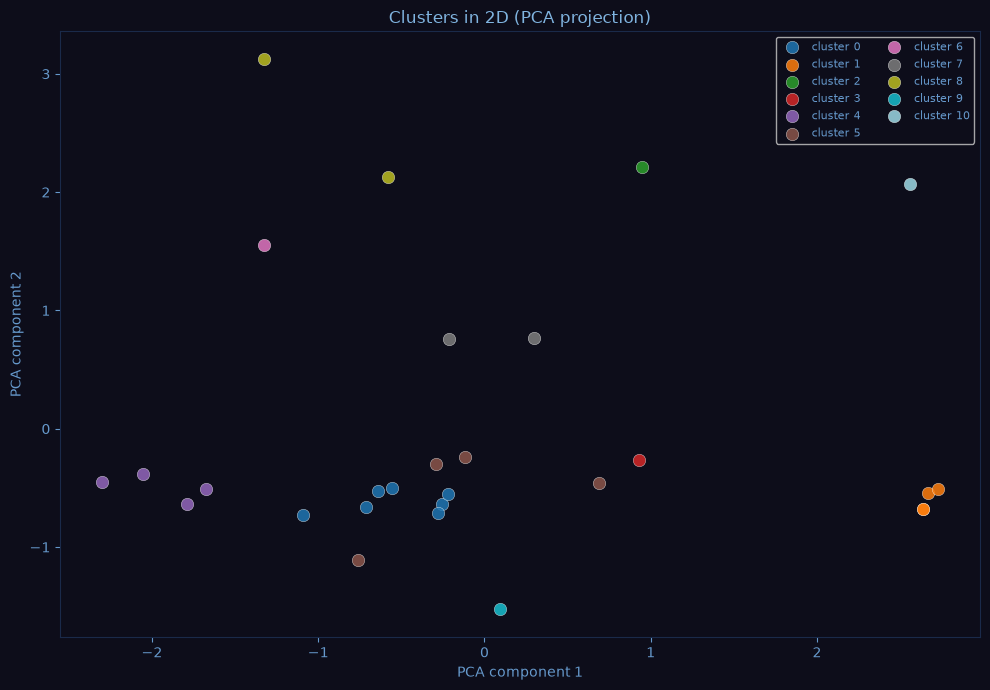

In [6]:
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_scaled)

print(f'PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'(how much info is preserved in the 2D view)')

fig, ax = plt.subplots(figsize=(10, 7), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.tick_params(colors='#6699cc')
ax.xaxis.label.set_color('#6699cc')
ax.yaxis.label.set_color('#6699cc')
for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

colors = plt.cm.tab20(np.linspace(0, 1, K))
for k in range(K):
    mask = labels == k
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
               color=colors[k], label=f'cluster {k}', s=80, alpha=0.85, edgecolors='white', linewidths=0.3)

ax.set(title='Clusters in 2D (PCA projection)', xlabel='PCA component 1', ylabel='PCA component 2')
ax.title.set_color('#80b4e0')
ax.legend(facecolor='#0d0d1a', labelcolor='#6699cc', ncol=2, fontsize=8)
plt.tight_layout()

## Visualize clusters over time
Plot which cluster each unit belongs to in the order they appear in the audio.

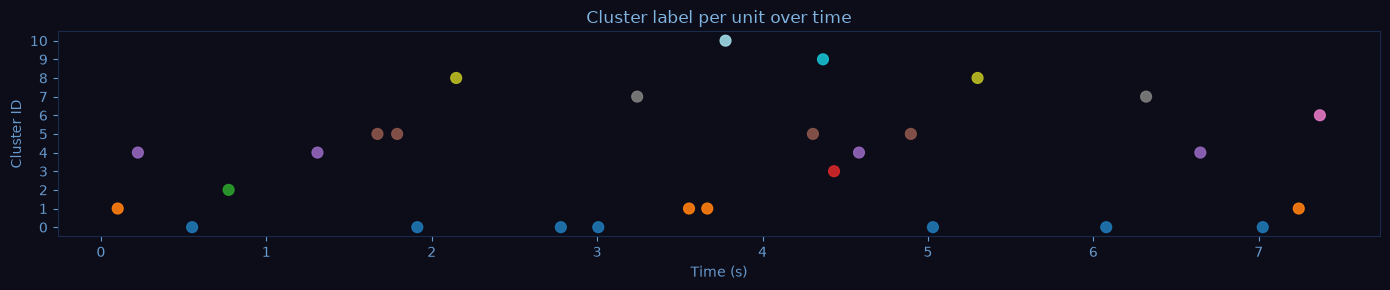

sequence of cluster labels (= Rocky decoded into cluster IDs):
[1, 4, 0, 2, 4, 5, 5, 0, 8, 0, 0, 7, 1, 1, 10, 5, 9, 3, 4, 5, 0, 8, 0, 7, 4, 0, 1, 6]


In [7]:
fig, ax = plt.subplots(figsize=(14, 3), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.tick_params(colors='#6699cc')
ax.xaxis.label.set_color('#6699cc')
ax.yaxis.label.set_color('#6699cc')
for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

ax.scatter(onset_times, labels, c=labels, cmap='tab20', s=60, alpha=0.9)
ax.set(title='Cluster label per unit over time', xlabel='Time (s)', ylabel='Cluster ID')
ax.title.set_color('#80b4e0')
ax.set_yticks(range(K))
plt.tight_layout()
plt.savefig('../audio/clusters_timeline.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

print('sequence of cluster labels (= Rocky decoded into cluster IDs):')
print(labels.tolist())

## Check cluster quality — compare to ground truth
We know the true sound name for each unit (from synthesis). How well did clustering recover them?

In [8]:
with open('../data/dictionary.json', 'r') as f:
    dictionary = json.load(f)

# rebuild ground truth labels from sentences
true_labels = []
sound_names = list(dictionary['vocabulary'])
for sentence in dictionary['sentences'].values():
    for sound in sentence:
        true_labels.append(sound)

# only compare up to the number of units we detected
n = min(len(true_labels), len(labels))
true_labels = true_labels[:n]

print('ground truth vs detected cluster (first 20 units):')
print(f'{"unit":6} {"true sound":20} {"cluster":8}')
print('-' * 36)
for i in range(min(20, n)):
    print(f'{i:6} {true_labels[i]:20} {labels[i]:8}')

ground truth vs detected cluster (first 20 units):
unit   true sound           cluster 
------------------------------------
     0 click_high                  1
     1 click_high                  4
     2 hum_mid                     0
     3 chirp_up                    2
     4 click_mid                   4
     5 hum_low                     5
     6 click_mid                   5
     7 click_low                   0
     8 chirp_up                    8
     9 chirp_up                    0
    10 chirp_down                  0
    11 chirp_down                  7
    12 chord_alien                 1
    13 click_high                  1
    14 click_high                 10
    15 click_high                  5
    16 chord_simple                9
    17 hum_mid                     3
    18 click_low                   4
    19 hum_high                    5


## Save cluster assignments

In [10]:
np.save('../data/cluster_labels.npy', labels)

# build cluster → most common true sound mapping
from collections import Counter
cluster_map = {}
for k in range(K):
    sounds_in_cluster = [true_labels[i] for i in range(n) if labels[i] == k]
    if sounds_in_cluster:
        most_common = Counter(sounds_in_cluster).most_common(1)[0][0]
        cluster_map[str(k)] = most_common

dictionary['cluster_map'] = cluster_map
with open('../data/dictionary.json', 'w') as f:
    json.dump(dictionary, f, indent=2)

print('cluster → sound name mapping:')
for k, sound in cluster_map.items():
    print(f'  cluster {k:2} → {sound}')
print()
print('saved  data/cluster_labels.npy')
print('saved  data/dictionary.json  updated')


cluster → sound name mapping:
  cluster 0  → hum_mid
  cluster 1  → click_high
  cluster 2  → chirp_up
  cluster 3  → hum_mid
  cluster 4  → click_high
  cluster 5  → hum_low
  cluster 7  → chirp_down
  cluster 8  → chirp_up
  cluster 9  → chord_simple
  cluster 10 → click_high

saved  data/cluster_labels.npy
saved  data/dictionary.json  updated
